In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Qwen/Qwen1.5-MoE-A2.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto"
)
model.eval()

/home/user2/miniforge3/envs/giangntt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 8/8 [00:05<00:00,  1.55it/s]


Qwen2MoeForCausalLM(
  (model): Qwen2MoeModel(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-23): 24 x Qwen2MoeDecoderLayer(
        (self_attn): Qwen2MoeSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): Qwen2MoeRotaryEmbedding()
        )
        (mlp): Qwen2MoeSparseMoeBlock(
          (gate): Linear(in_features=2048, out_features=60, bias=False)
          (experts): ModuleList(
            (0-59): 60 x Qwen2MoeMLP(
              (gate_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (up_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (down_proj): Linear(in_features=1408, out_features=2048, bias=False)
        

In [2]:
# Prepare MMLU prompts using utility function
from utils.data_utils import prepare_mmlu_prompts

topic = "stem"  # Options: "humanities", "social_sciences", "stem", "other". For the “other” subtask, a general dataset like C4 may be a better choice for profiling.
prompts = prepare_mmlu_prompts(topic=topic, max_samples_per_subject=5)

In [14]:
topic = "other"
from datasets import load_dataset
import random

ds = load_dataset("brando/small-c4-dataset", split="train")
texts = ds["text"]

prompts = random.sample(texts, 128)

In [ ]:
topic = "math"
# Prepare GSM8K prompts using utility function
from utils.data_utils import prepare_gsm8k_prompts

prompts = prepare_gsm8k_prompts(sample_size=50)

In [3]:
# Register hooks and collect router logits
from utils.hook_utils import ExpertActivationHook
from utils.router_utils import collect_router_logits

# Create hook manager and register hooks
hook_manager = ExpertActivationHook()
hook_manager.register_hooks(model)

# Collect router logits
result = collect_router_logits(model, tokenizer, prompts, DEVICE)
full_router_logits = result['router_logits']

# Get expert activations and clear hooks
full_expert_activations = hook_manager.expert_activations
hook_manager.clear_hooks()

In [4]:
# Compute router statistics using utility functions
from utils.analysis_utils import compute_all_stats

full_stats = compute_all_stats(
    router_logits=full_router_logits,
    expert_activations=full_expert_activations,
    top_k=4)

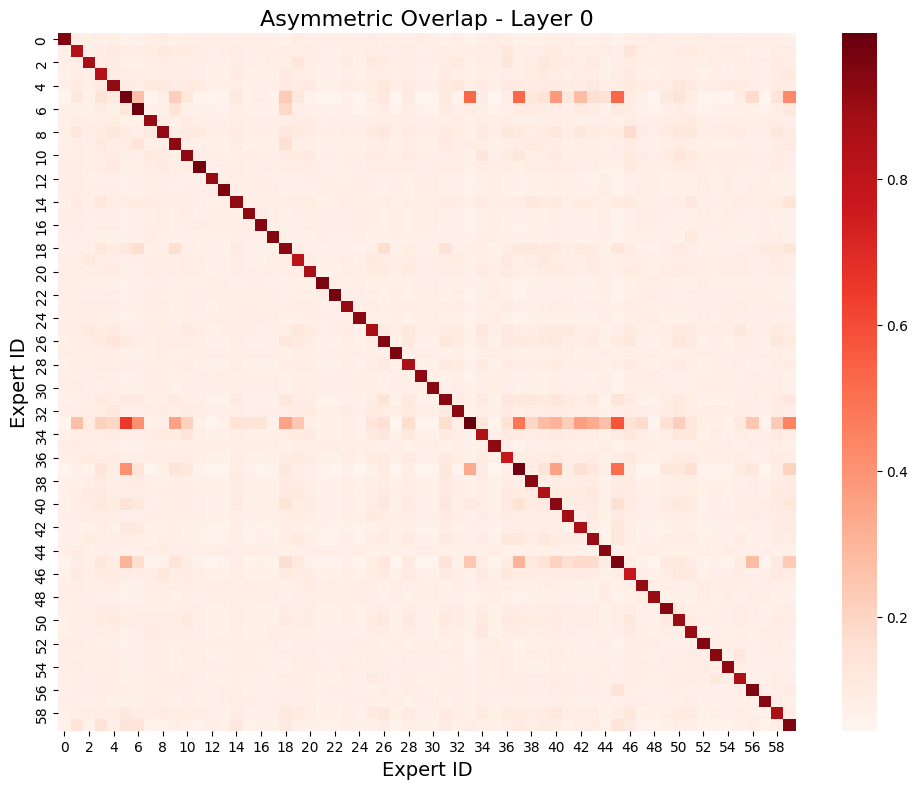

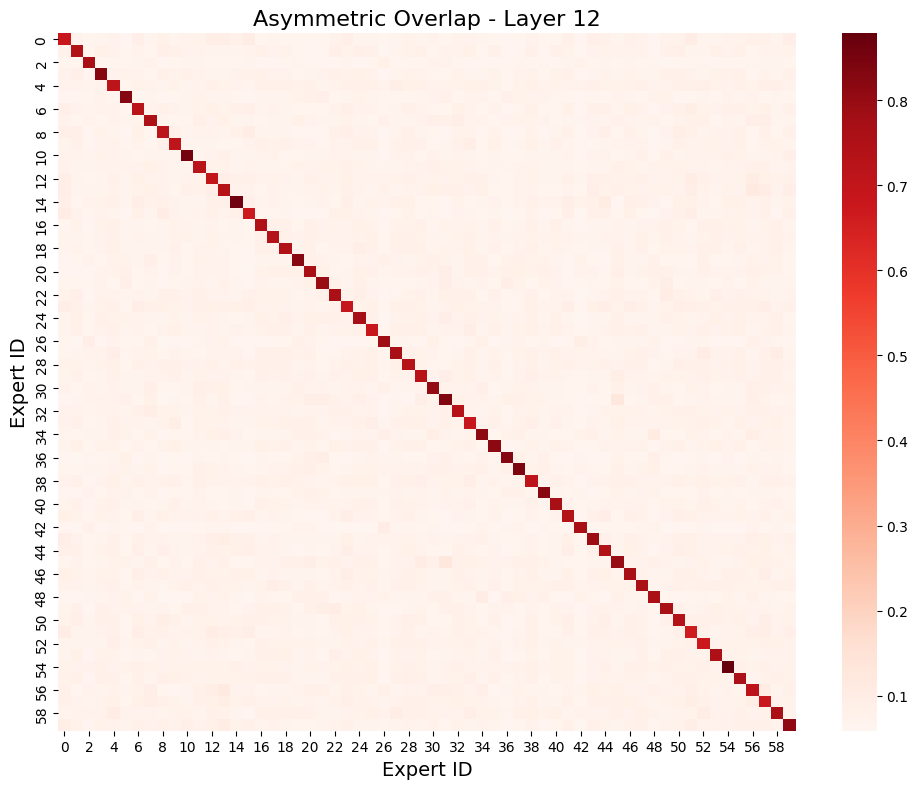

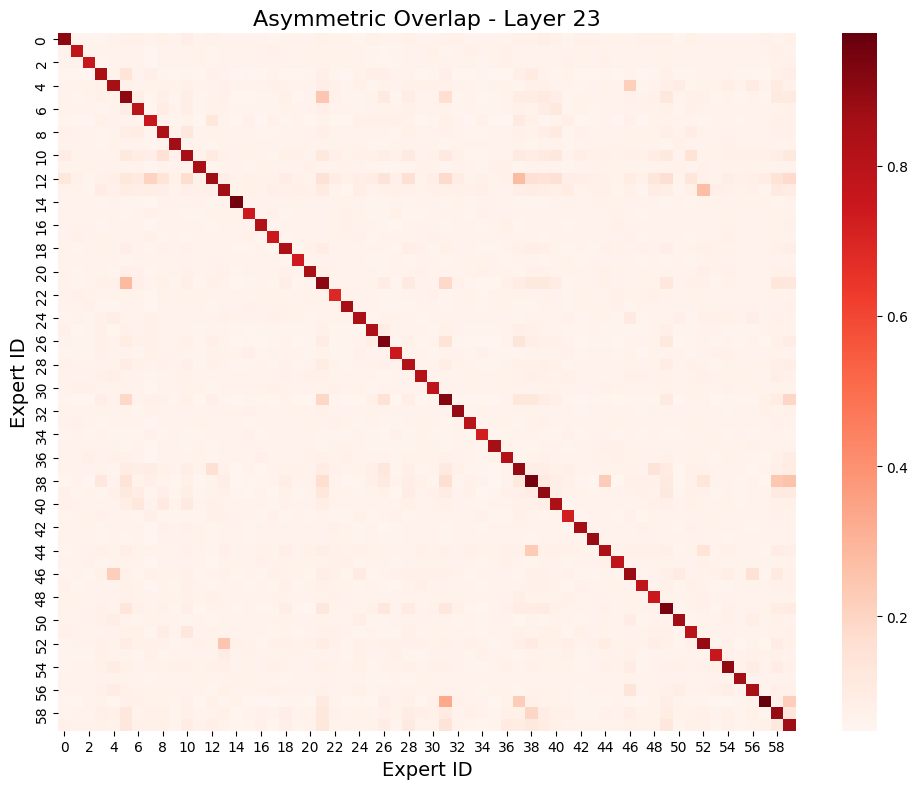

: 

In [ ]:
# Use utility function for asymmetric overlap computation
from utils.analysis_utils import compute_asymmetric_overlap_matrix
from utils.visualization_utils import plot_matrix
layers_to_plot = [0, 12, 23]  # Adjust based on model depth
for layer in layers_to_plot:
    asym_overlap = compute_asymmetric_overlap_matrix(
        full_expert_activations,
        layer_id=layer,
        rank=128,
        sample_tokens=2000,
        device='cuda'
    )
    plot_matrix(asym_overlap, title=f"Asymmetric Overlap - Layer {layer}", 
                xlabel="Expert ID", ylabel="Expert ID", cmap="Reds", annot=False)

In [ ]:
# Build and save experts sorted by increasing mean activation norm (act) per layer
# Uses `full_stats` computed earlier: full_stats[layer_id]['mean_act'] -> array of mean norms per expert
import json
import numpy as np
import os

sorted_experts_by_act = {}
for layer_id, stats in sorted(full_stats.items()):
    mean_act = np.array(stats.get('mean_act', []))
    if mean_act.size == 0:
        # no data for this layer; store empty list
        sorted_experts_by_act[int(layer_id)] = []
        continue
    # argsort gives indices that would sort mean_act ascending (increasing norm)
    order = np.argsort(mean_act).tolist()
    sorted_experts_by_act[int(layer_id)] = order

# Save to a JSON file so downstream cells/scripts can load it
out_dir = 'final_outputs/statistics/all_layers'
os.makedirs(out_dir, exist_ok=True)

# topic = 'stem'
out_path = f'{out_dir}/{topic}_sorted_by_act_asc.json'
with open(out_path, 'w') as f:
    json.dump(sorted_experts_by_act, f, indent=2)

print(f'Saved sorted experts by increasing mean act norm for {len(sorted_experts_by_act)} layers to {out_path}')


Saved sorted experts by increasing mean act norm for 24 layers to final_outputs/statistics/all_layers/stem_sorted_by_act_asc.json


In [ ]:
# Create a pruned model
import copy
import gc
import torch

# Clean up memory first
if 'pruned_model' in locals():
    pruned_model.to("cpu")
    del pruned_model

model.to("cpu")  # Move model back to CPU
gc.collect()
torch.cuda.empty_cache()
# # Create a new copy of the original model for layer pruning
pruned_model = copy.deepcopy(model)
pruned_model.to("cuda")
pruned_model.eval()

Qwen2MoeForCausalLM(
  (model): Qwen2MoeModel(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-23): 24 x Qwen2MoeDecoderLayer(
        (self_attn): Qwen2MoeSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): Qwen2MoeRotaryEmbedding()
        )
        (mlp): Qwen2MoeSparseMoeBlock(
          (gate): Linear(in_features=2048, out_features=60, bias=False)
          (experts): ModuleList(
            (0-59): 60 x Qwen2MoeMLP(
              (gate_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (up_proj): Linear(in_features=2048, out_features=1408, bias=False)
              (down_proj): Linear(in_features=1408, out_features=2048, bias=False)
        

In [5]:
from utils.common_utils import get_topk_experts_from_json
experts_to_prune = get_topk_experts_from_json("final_outputs/statistics/humanities_norm_var_act_below_midrange.json", top_k=30, mode="most", layers_to_prune=list(range(1, 23)))

from utils.model_utils import apply_pruning
apply_pruning(pruned_model, experts_to_prune)

Loaded 'final_outputs/statistics/humanities_norm_var_act_below_midrange.json' and produced top-30 most used/important experts per layer (criterion=None)
Filtered to layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Layers: 22, total experts selected: 304


In [ ]:
# Register hooks and collect router logits for pruned model
from utils.hook_utils import ExpertActivationHook
from utils.router_utils import collect_router_logits

# Create hook manager and register hooks
pruned_hook_manager = ExpertActivationHook()
pruned_hook_manager.register_hooks(pruned_model)

# Collect router logits
result = collect_router_logits(pruned_model, tokenizer, prompts, DEVICE)
router_logits = result['router_logits']

# Get expert activations and clear hooks
expert_activations = pruned_hook_manager.expert_activations
pruned_hook_manager.clear_hooks()

Inferring prompts: 100%|██████████| 65/65 [00:14<00:00,  4.49it/s]


In [ ]:
# Compare logits using utility function
from utils.analysis_utils import compare_logits

sim_results = compare_logits(full_final_logits, final_logits)

print("Average token-level similarity per sequence:", sim_results['avg_token_cos'])
print("Sequence-level cosine similarity:", sim_results['sequence_cos'])
print("Sequence-level KL divergence:", sim_results['sequence_kl'])

Average token-level similarity per sequence: [0.8918032646179199, 0.8681042194366455, 0.8820451498031616, 0.8230056762695312, 0.8618879318237305, 0.8639654517173767, 0.8916941285133362, 0.824222207069397, 0.8874655961990356, 0.8463922739028931, 0.8541326522827148, 0.8746011853218079, 0.8271820545196533, 0.8698133230209351, 0.8633211255073547, 0.911128580570221, 0.8343290686607361, 0.8610407114028931, 0.8463395833969116, 0.8789369463920593, 0.8716662526130676, 0.8711682558059692, 0.8417828679084778, 0.8661275506019592, 0.8817099332809448, 0.8500002026557922, 0.8060497045516968, 0.8950278162956238, 0.8819117546081543, 0.8574569821357727, 0.8680828809738159, 0.8785774111747742, 0.8838961124420166, 0.882956862449646, 0.8480213284492493, 0.8661933541297913, 0.8530886769294739, 0.8468385934829712, 0.8490046858787537, 0.8867461681365967, 0.8871304988861084, 0.8552126288414001, 0.853151798248291, 0.8502339124679565, 0.8475157022476196, 0.8844297528266907, 0.8855589628219604, 0.881528377532959,

In [7]:
import torch

# 1️⃣ Total tokens
total_tokens = 0
for prompt in prompts:
    tokens = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)
    total_tokens += tokens['input_ids'].numel()  # batch_size * seq_len for this prompt
print(f"Total tokens in dataset: {total_tokens}")

# 2️⃣ Total expert activations from hooks
total_full_expert_activations = 0
total_pruned_expert_activations = 0
for layer_id, acts_list in full_expert_activations.items():
    for acts in acts_list:
        total_full_expert_activations += acts.shape[0]  # each row = one token routed to an expert

print(f"Total expert activations (from hooks): {total_full_expert_activations}")

for layer_id, acts_list in expert_activations.items():
    for acts in acts_list:
        total_pruned_expert_activations += acts.shape[0]  # each row = one token routed to an expert

print(f"Total expert activations (from hooks): {total_pruned_expert_activations}")


Total tokens in dataset: 10175
Total expert activations (from hooks): 976800
Total expert activations (from hooks): 805392


In [ ]:

# Compare full_expert_activations (pre-prune) and expert_activations (post-prune)
from utils.analysis_utils import summarize_pruned_experts

# Run the summary using the variables already present in the notebook
per_layer_summary, disabled_keys = summarize_pruned_experts(full_expert_activations, expert_activations, top_k_per_layer=5)

Per-layer pruning summary:
- Layer 0: experts_original=60, disabled=0, tokens_original=12804, tokens_disabled=0 (0.00% of layer tokens)
- Layer 1: experts_original=60, disabled=20, tokens_original=12804, tokens_disabled=3372 (26.34% of layer tokens)
   top disabled experts (expert_id, tokens): [(5, 250), (3, 248), (43, 242), (32, 231), (58, 222)]
- Layer 2: experts_original=60, disabled=20, tokens_original=12804, tokens_disabled=3421 (26.72% of layer tokens)
   top disabled experts (expert_id, tokens): [(57, 435), (39, 264), (13, 260), (24, 190), (30, 186)]
- Layer 3: experts_original=60, disabled=20, tokens_original=12804, tokens_disabled=4134 (32.29% of layer tokens)
   top disabled experts (expert_id, tokens): [(19, 470), (33, 361), (35, 326), (51, 289), (18, 262)]
- Layer 4: experts_original=60, disabled=20, tokens_original=12804, tokens_disabled=3475 (27.14% of layer tokens)
   top disabled experts (expert_id, tokens): [(41, 323), (25, 314), (20, 255), (24, 234), (1, 225)]
- Layer

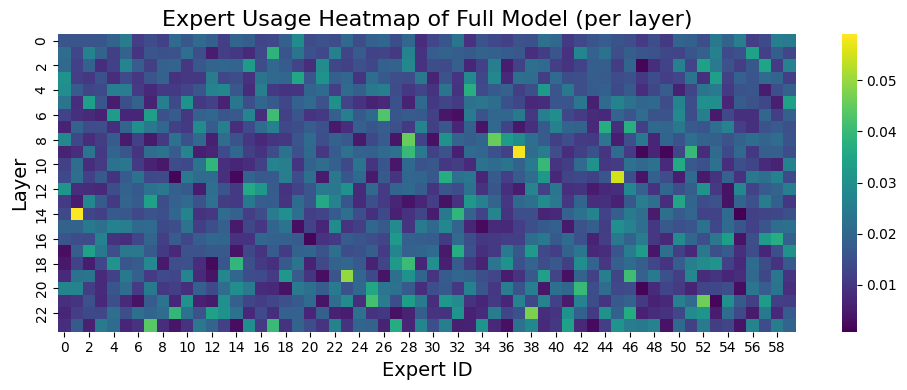

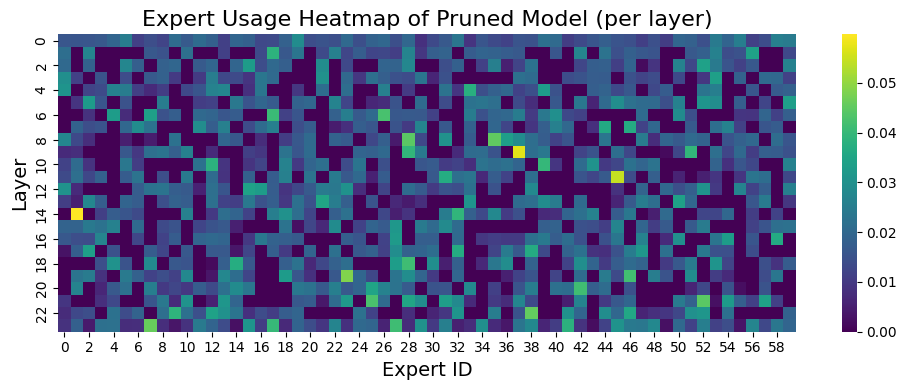

In [10]:
from utils.visualization_utils import plot_bar, plot_matrix, plot_histogram
from utils.analysis_utils import analyze_expert_usage_entropy

full_layer_entropy, full_expert_usage = analyze_expert_usage_entropy(full_router_logits, top_k=4)

# ---- plot expert usage heatmap ----
full_usage_matrix = torch.stack(full_expert_usage).numpy()  # [num_layers, num_experts]
plot_matrix(
    full_usage_matrix,
    figsize=(10, 4),
    cmap="viridis",
    xlabel="Expert ID",
    ylabel="Layer",
    title="Expert Usage Heatmap of Full Model (per layer)",
    # output_file=f"{plot_output_dir}/expert_usage_heatmap.png"
)

pruned_layer_entropy, pruned_expert_usage = analyze_expert_usage_entropy(router_logits, top_k=4)

# ---- plot expert usage heatmap ----
pruned_usage_matrix = torch.stack(pruned_expert_usage).numpy()  # [num_layers, num_experts]

# Ensure any explicitly pruned experts are zeroed out in the matrix (robustness in case analyzer didn't)
if 'experts_to_prune' in globals() and experts_to_prune is not None:
    # experts_to_prune can be a dict mapping layer->list or a flat iterable of ints
    num_layers = pruned_usage_matrix.shape[0]
    for layer_idx in range(num_layers):
        pruned = []
        if isinstance(experts_to_prune, dict):
            pruned = list(experts_to_prune.get(layer_idx, []))
        else:
            try:
                pruned = list(experts_to_prune)
            except Exception:
                pruned = []
        # Filter valid indices and zero them
        valid = [int(i) for i in pruned if 0 <= int(i) < pruned_usage_matrix.shape[1]]
        if len(valid) > 0:
            pruned_usage_matrix[layer_idx, valid] = 0.0

plot_matrix(
    pruned_usage_matrix,
    figsize=(10, 4),
    cmap="viridis",
    xlabel="Expert ID",
    ylabel="Layer",
    title="Expert Usage Heatmap of Pruned Model (per layer)",
    # output_file=f"{output_dir}/expert_usage_heatmap.png"
)

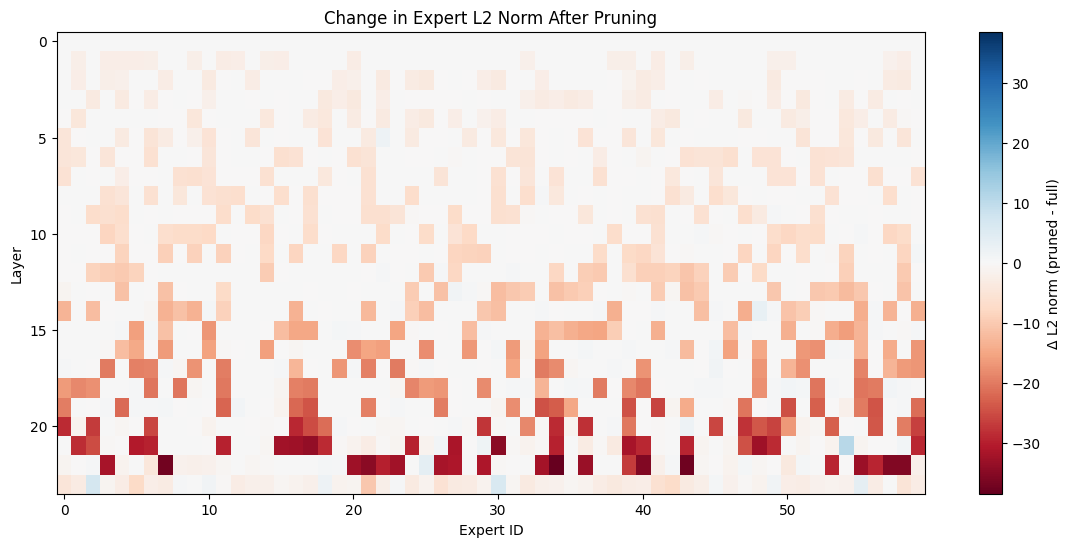

In [ ]:
# Aggregate norm statistics using utility function
import numpy as np
import matplotlib.pyplot as plt
from utils.analysis_utils import aggregate_norm_stats

full_norm_stats = aggregate_norm_stats(full_expert_activations)
pruned_norm_stats = aggregate_norm_stats(expert_activations)

layers = sorted(set(k[0] for k in full_norm_stats))
experts = sorted(set(k[1] for k in full_norm_stats))

diff = np.zeros((len(layers), len(experts)))
for (l, e) in full_norm_stats:
    diff[l, e] = pruned_norm_stats.get((l, e), 0) - full_norm_stats[(l, e)]

plt.figure(figsize=(14,6))
plt.imshow(diff, aspect='auto', cmap='RdBu', vmin=-abs(diff).max(), vmax=abs(diff).max())
plt.colorbar(label='Δ L2 norm (pruned - full)')
plt.xlabel('Expert ID')
plt.ylabel('Layer')
plt.title('Change in Expert L2 Norm After Pruning')
plt.show()



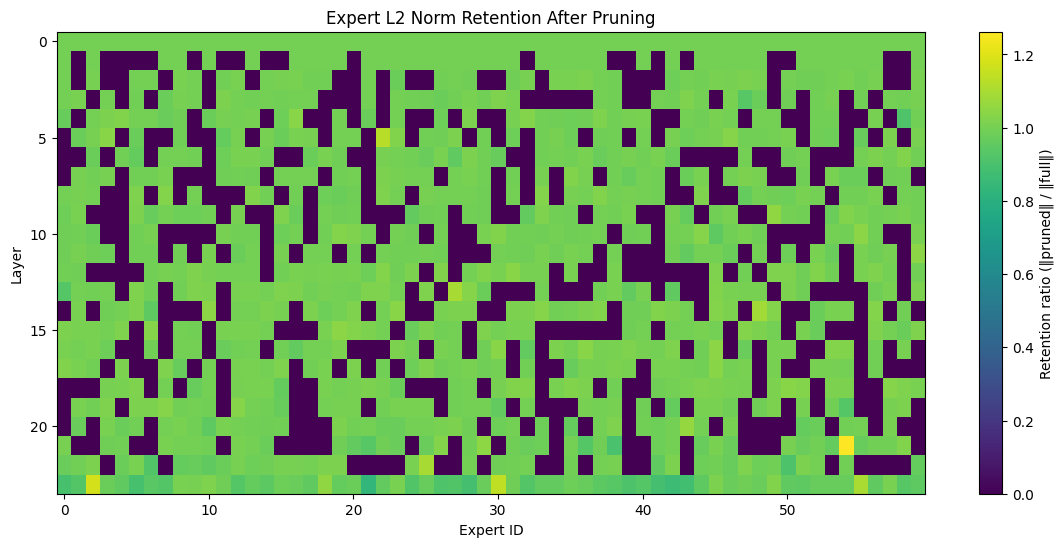

In [ ]:
ratio = np.zeros((len(layers), len(experts)))
for (l, e) in full_norm_stats:
    base = full_norm_stats[(l, e)]
    ratio[l, e] = pruned_norm_stats.get((l, e), 0) / (base + 1e-8)

plt.figure(figsize=(14,6))
plt.imshow(ratio, aspect='auto', cmap='viridis')
plt.colorbar(label='Retention ratio (‖pruned‖ / ‖full‖)')
plt.xlabel('Expert ID')
plt.ylabel('Layer')
plt.title('Expert L2 Norm Retention After Pruning')
plt.show()


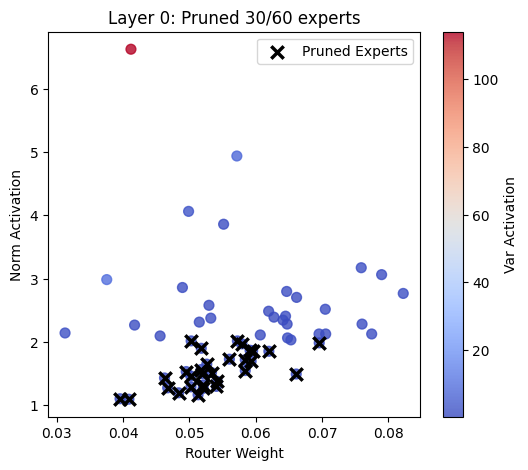

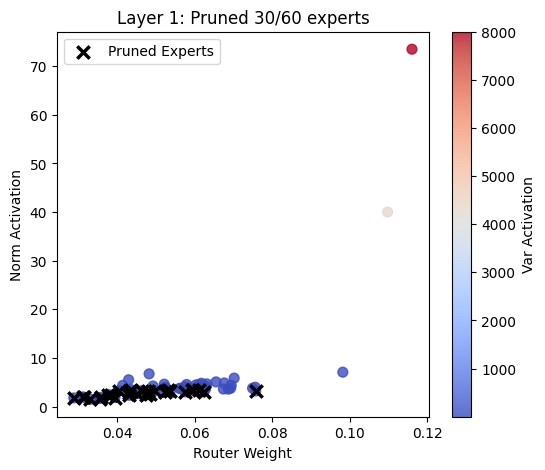

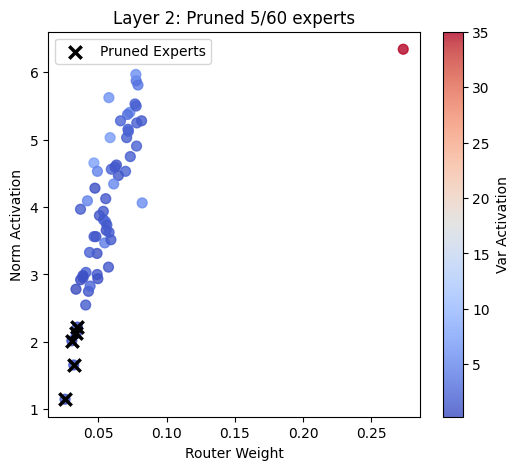

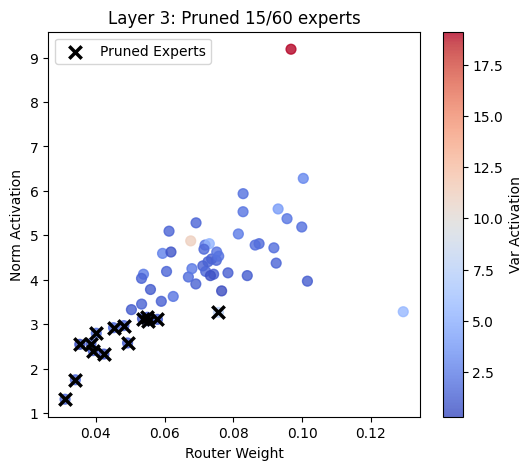

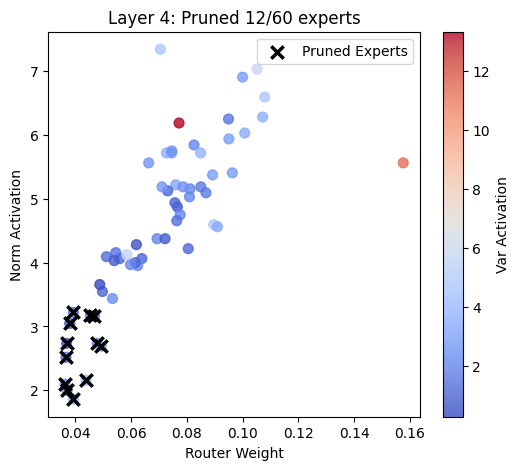

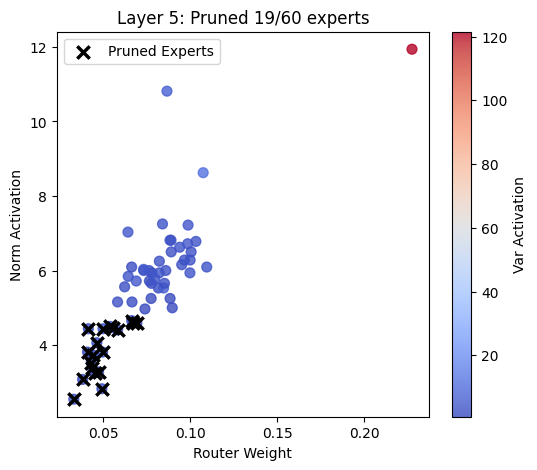

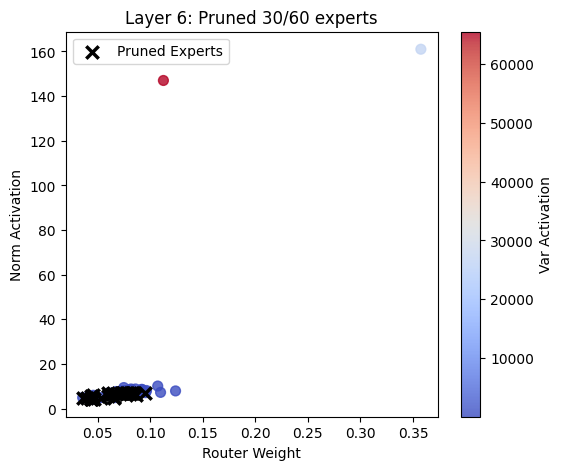

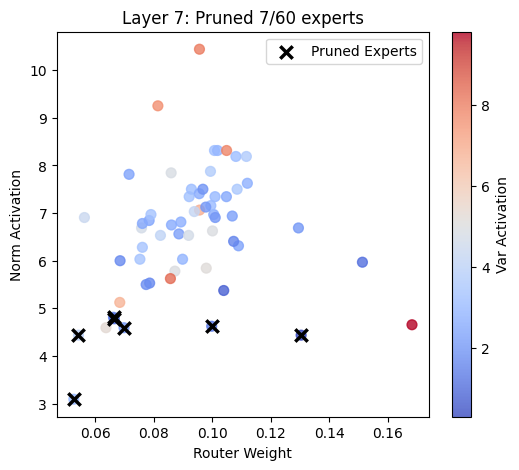

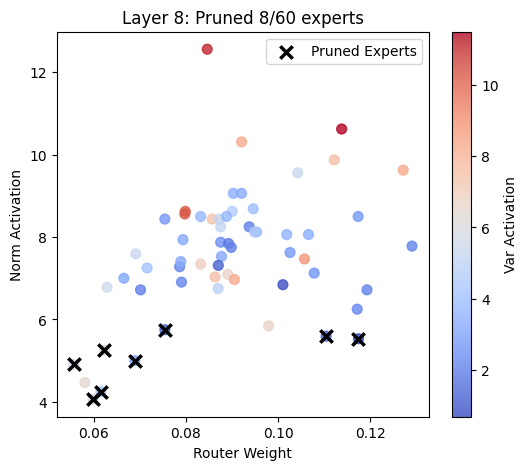

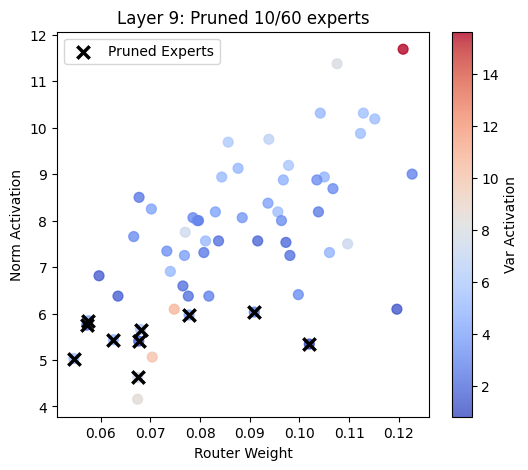

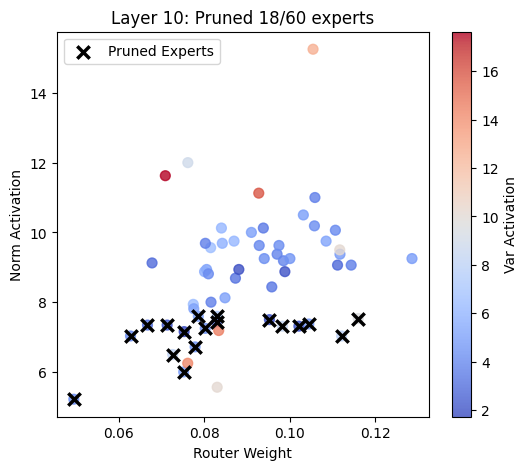

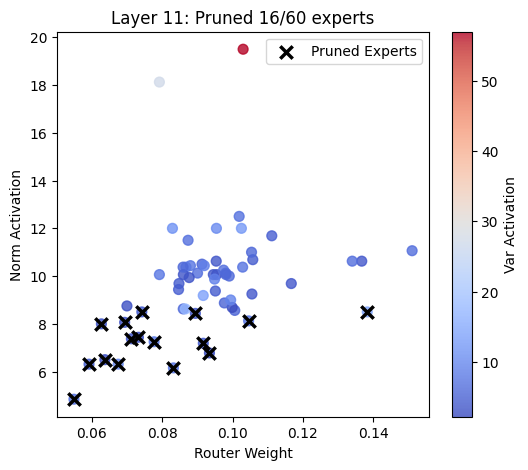

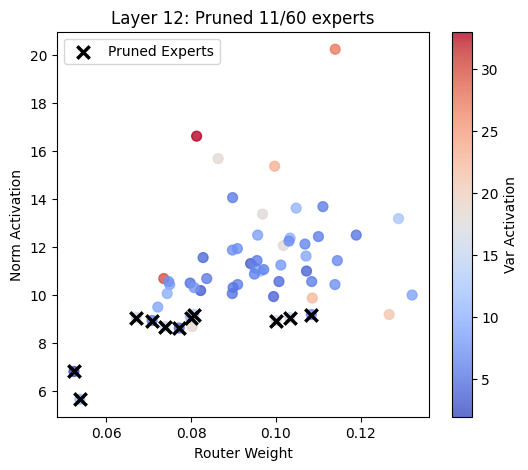

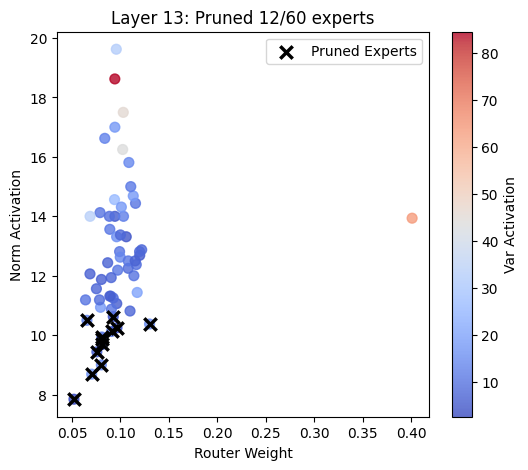

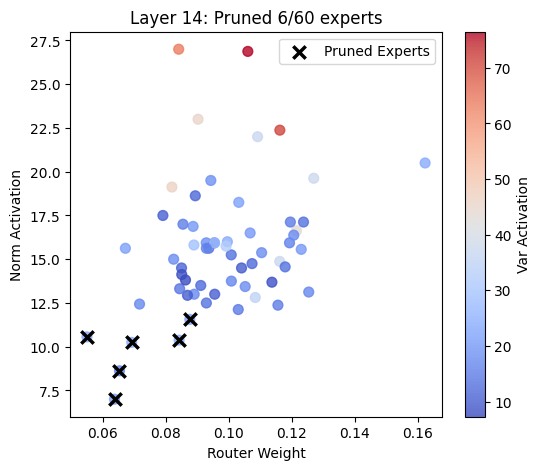

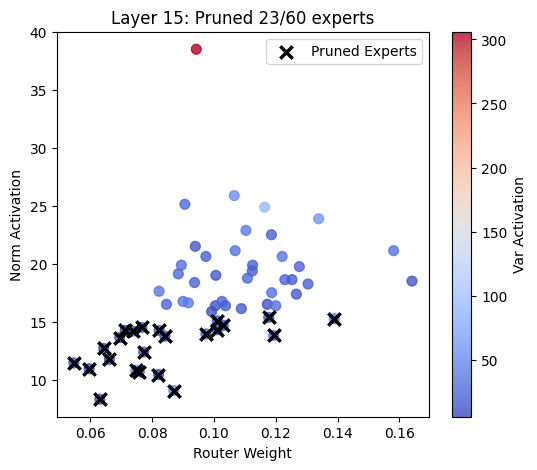

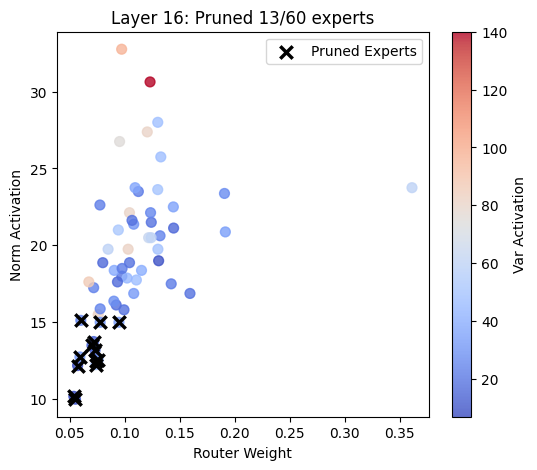

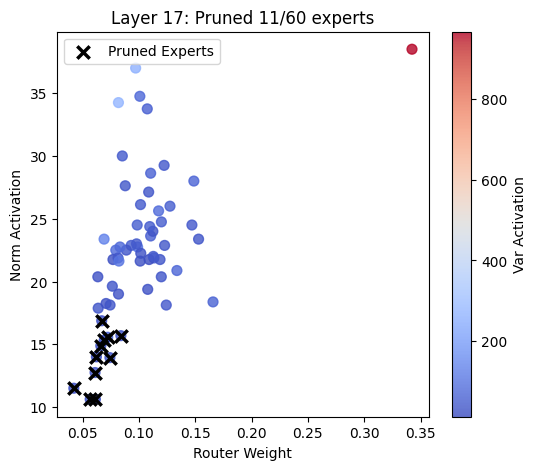

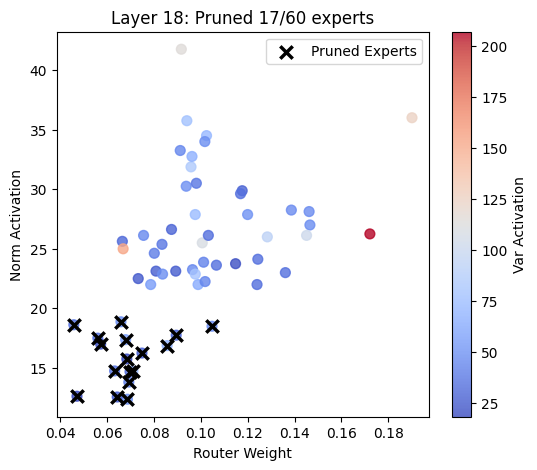

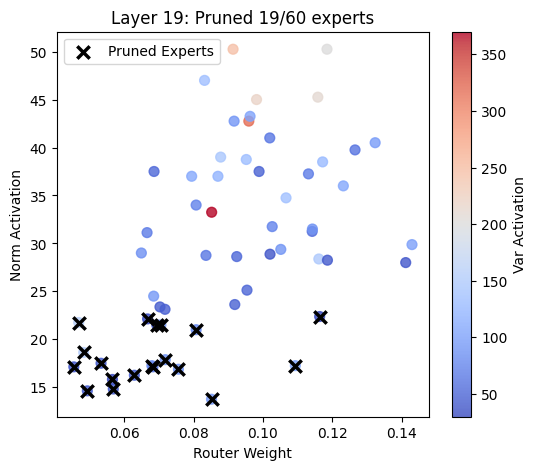

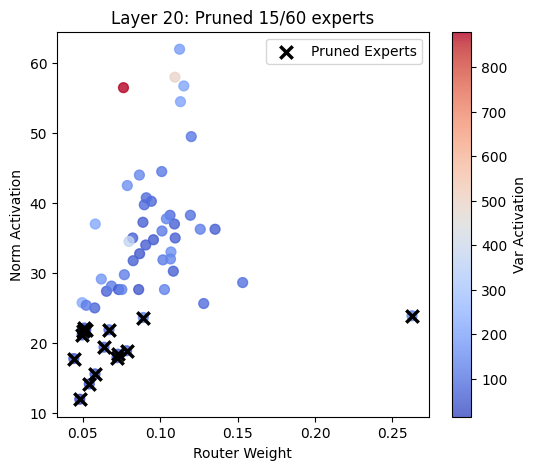

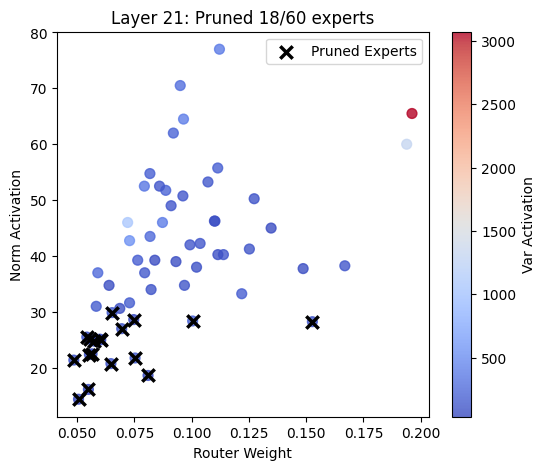

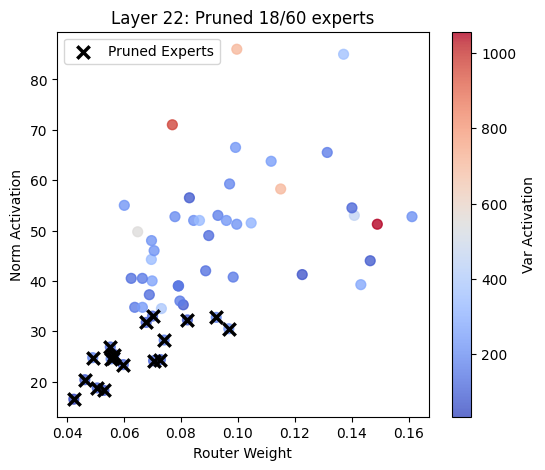

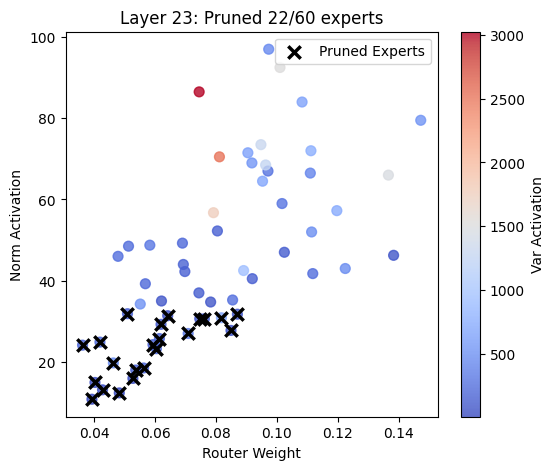

Total pruned experts: 385


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json

pruned_summary = {}  # to store pruned experts per layer

layers_to_plot = list(range(0, 24))
max_pruned_exprts_per_layer = 30

for layer_id in layers_to_plot:
    stats = full_stats[layer_id]
    cond_mean = np.array(stats["cond_mean"])
    mean_act = np.array(stats["mean_act"])
    var_act = np.array(stats["var_act"])

    # ----------------------------
    # 1️⃣ Normalize to 0-1
    mean_act_norm = (mean_act - mean_act.min()) / (mean_act.max() - mean_act.min() + 1e-12)
    var_act_norm = (var_act - var_act.min()) / (var_act.max() - var_act.min() + 1e-12)

    # 2️⃣ Middle of value range
    mean_act_mid = (mean_act_norm.min() + mean_act_norm.max()) / 2 / 2  # then divide by 2
    var_act_mid  = (var_act_norm.min() + var_act_norm.max()) / 2

    # 3️⃣ Pruning rule
    pruned_mask = (mean_act_norm < mean_act_mid) & (var_act_norm < var_act_mid)

    # Limit to max 30 pruned experts per layer
    pruned_indices = np.where(pruned_mask)[0]
    if len(pruned_indices) > max_pruned_exprts_per_layer:
        # keep 30 lowest mean_act_norm
        idx_sort = np.argsort(mean_act_norm[pruned_indices])
        pruned_indices = pruned_indices[idx_sort[:max_pruned_exprts_per_layer]]

    kept_mask = np.ones_like(mean_act, dtype=bool)
    kept_mask[pruned_indices] = False

    pruned_summary[layer_id] = pruned_indices.tolist()

    # Count pruned experts
    num_pruned = len(pruned_indices)
    total_experts = len(pruned_mask)

    # ----------------------------
    # Plot
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        cond_mean,
        mean_act,
        c=var_act,
        cmap="coolwarm",
        s=50,
        alpha=0.8,
        zorder=1
    )

    # Overlay X markers for pruned experts
    if num_pruned > 0:
        plt.scatter(
            cond_mean[pruned_indices],
            mean_act[pruned_indices],
            color="black",
            marker="x",
            s=80,
            linewidths=2.5,
            label="Pruned Experts",
            zorder=3
        )

    plt.xlabel("Router Weight")
    plt.ylabel("Norm Activation")
    plt.title(f"Layer {layer_id}: Pruned {num_pruned}/{total_experts} experts")
    plt.colorbar(scatter, label="Var Activation")
    plt.legend()
    plt.show()

# Save summary to JSON file
outdir = "final_outputs/statistics/all_layers"
os.makedirs(outdir, exist_ok=True)
outfile = f"{outdir}/{topic}_norm_var_act_below_midrange.json"
with open(outfile, "w") as f:
    json.dump(pruned_summary, f, indent=2)

print(f"✅ Saved pruned expert indices to {outfile}")
# Compute and print total number of pruned experts across all layers
total_pruned_experts = sum(len(v) for v in pruned_summary.values())
print(f"Total pruned experts: {total_pruned_experts}")

In [15]:
import torch.nn.functional as F
for layer in full_router_logits.keys():
    # Flatten all tokens in the batch
    f_logits = full_router_logits[layer].reshape(-1, full_router_logits[layer].size(-1))
    p_logits = router_logits[layer].reshape(-1, router_logits[layer].size(-1))

    # Normalize
    f_norm = F.normalize(f_logits, dim=1)
    p_norm = F.normalize(p_logits, dim=1)

    # Compute cosine similarity per token
    cos_sim = (f_norm * p_norm).sum(dim=1)

    # Average across all tokens
    mean_cosine_sim = cos_sim.mean().item()
    print(f"Mean cosine similarity between full and pruned logits: {mean_cosine_sim:.4f}")


Mean cosine similarity between full and pruned logits: 1.0000
Mean cosine similarity between full and pruned logits: 1.0000
Mean cosine similarity between full and pruned logits: 0.9999
Mean cosine similarity between full and pruned logits: 0.9999
Mean cosine similarity between full and pruned logits: 0.9998
Mean cosine similarity between full and pruned logits: 0.9997
Mean cosine similarity between full and pruned logits: 0.9997
Mean cosine similarity between full and pruned logits: 0.9997
Mean cosine similarity between full and pruned logits: 0.9996
Mean cosine similarity between full and pruned logits: 0.9995
Mean cosine similarity between full and pruned logits: 0.9995
Mean cosine similarity between full and pruned logits: 0.9994
Mean cosine similarity between full and pruned logits: 0.9993
Mean cosine similarity between full and pruned logits: 0.9992
Mean cosine similarity between full and pruned logits: 0.9991
Mean cosine similarity between full and pruned logits: 0.9990
Mean cos

In [ ]:
# Use utility function for threshold-based pruning
from utils.common_utils import prune_by_threshold

experts_to_prune = prune_by_threshold(
    all_stats=full_stats,
    method='std',
    router_param=-100,
    act_param=0,
    # save_path="statistics/mmlu_stem_combined_criteria/dynamic_normed_importance_k20.json",
    layers_to_prune=list(range(1, 23))
)